In [ ]:
import os
import sys


import sionna.rt as srt

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.abspath(_module_path))

from src.utils.rt_utils import init_scene, get_su_coordinates, get_random_tx_location, get_scene_size

COLOR_SU = (0.988, 0.937, 0)
COLOR_TX = (0, 1, 0.098)
COLOR_JAM = (1, 0.098, 0)

COLOR_METAL = (0.831, 0.867, 0.871)
COLOR_CONCRETE = (0.659, 0.616, 0.588)

In [ ]:
scene_nr = 0
f_c = 3.7e9     # in Hz
su_coordinates = get_su_coordinates(_module_path)


scene_path = os.path.join(
    _module_path, "scenes", f"scene{scene_nr}", "scene.xml"
)
scene = init_scene(scene_path, f_c, su_coordinates)

# remove the ceiling
scene.edit(remove="room_ceiling_object")

# adjust color for the receivers
for rx in scene.receivers:
    scene.receivers[rx].color = COLOR_SU

# add transmitters at random locations
n_tx = 5
tx_height = 1.5 # in m
for tx_idx in range(n_tx):
    tx_location = get_random_tx_location(scene_nr, get_scene_size(scene), tx_height)
    tx = srt.Transmitter(f"tx{tx_idx}", position=tx_location, color=COLOR_TX)
    scene.add(tx)

# add jammer
jammer_location = get_random_tx_location(scene_nr, get_scene_size(scene), tx_height)
jammer = srt.Transmitter("jammer", position=jammer_location, color=COLOR_JAM)
scene.add(jammer)
scene.preview()

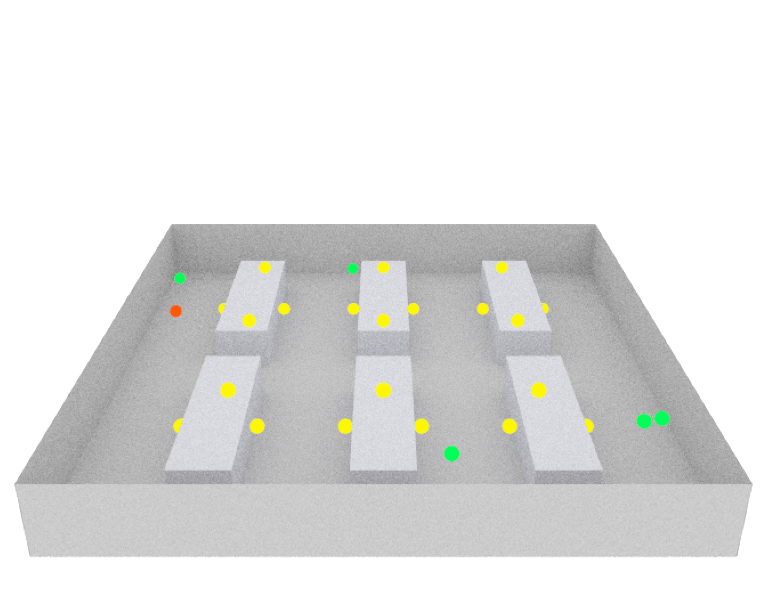

In [86]:
cam = srt.Camera(position=(20, -40, 35), look_at=(20, 35, 0))
scene.render(camera=cam, num_samples=32);

In [ ]:
scene.radio_materials.

{'itu-concrete': ITURadioMaterial type=concrete
                  eta_r=5.240
                  sigma=0.129
                  thickness=0.100
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000,
 'itu-metal': ITURadioMaterial type=metal
                  eta_r=1.000
                  sigma=10000000.000
                  thickness=0.100
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000,
 'concrete-room': ITURadioMaterial type=concrete
                  eta_r=5.240
                  sigma=0.129
                  thickness=0.200
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000,
 'concrete-ceiling': ITURadioMaterial type=concrete
                  eta_r=5.240
                  sigma=0.129
                  thickness=0.200
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000,
 'metal': ITURadioMaterial type=metal
                  eta_r=1.000
      